<a href="https://colab.research.google.com/github/Rame395/Machine-Learning/blob/main/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/full.csv')

In [ ]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   object 
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   object 
 16  Boarded      1304 non-null   object 
 17  Destination  1304 non-null   object 
 18  Lifeboat     502 non-null    object 
 19  Body  

In [ ]:
df.shape

(1309, 21)

In [ ]:
df=df.iloc[ : , 0: 12]

In [ ]:
df.shape

(1309, 21)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
numerical_columns = [col for col in df.columns if df[col].dtype != 'object']
print(f"Categorical Columns {categorical_columns}")
print(f"Numerical Columns {numerical_columns}")

Categorical Columns ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Name_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body']
Numerical Columns ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'WikiId', 'Age_wiki', 'Class']


In [ ]:
sex_count = df['Sex'].value_counts()

Text(0.5, 1.0, 'Sex Count')

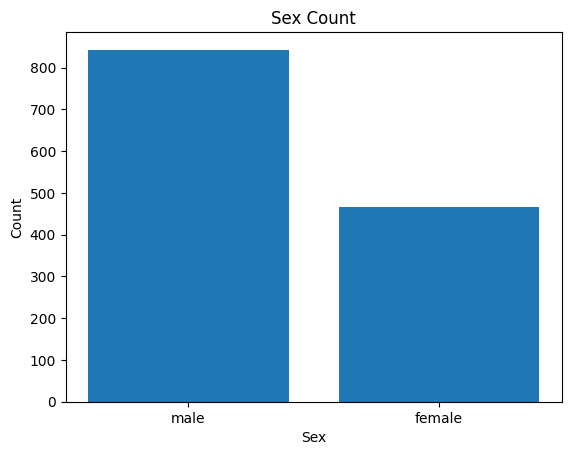

In [ ]:
plt.bar(sex_count.index, sex_count.values)
plt.xticks(sex_count.index)
plt.ylabel('Count')
plt.xlabel('Sex')
plt.title('Sex Count')

In [ ]:
round(df.isnull().sum()/ df.shape[0] * 100, 2)

,0
PassengerId,0.00
Survived,31.93
Pclass,0.00
Name,0.00
Sex,0.00
Age,20.09
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.08


In [ ]:
df1 = df.drop (columns = ['Name', 'Ticket', 'Cabin'])
df1.dropna(subset = ['Embarked'], inplace=True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())

In [ ]:
df1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,male,22.000000,1,0,7.2500,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,female,38.000000,1,0,71.2833,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,female,26.000000,0,0,7.9250,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,female,35.000000,1,0,53.1000,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,male,35.000000,0,0,8.0500,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,male,29.842596,0,0,8.0500,S,1227.0,"Spector, Mr. Woolf",23.0,"London, England",Southampton,New York City,NaN,NaN,3.0
1305,1306,NaN,1,female,39.000000,0,0,108.9000,C,229.0,"and maid, Doña Fermina Oliva y Ocana",39.0,"Madrid, Spain",Cherbourg,"New York, New York, US",8,NaN,1.0
1306,1307,NaN,3,male,38.500000,0,0,7.2500,S,1169.0,"Sæther, Mr. Simon Sivertsen",43.0,"Skaun, Sør-Trøndelag, Norway",Southampton,US,NaN,32MB,3.0
1307,1308,NaN,3,male,29.842596,0,0,8.0500,S,1289.0,"Ware, Mr. Frederick William",34.0,"Greenwich, London, England",Southampton,New York City,NaN,NaN,3.0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1307 non-null   int64  
 1   Survived     889 non-null    float64
 2   Pclass       1307 non-null   int64  
 3   Sex          1307 non-null   object 
 4   Age          1307 non-null   float64
 5   SibSp        1307 non-null   int64  
 6   Parch        1307 non-null   int64  
 7   Fare         1306 non-null   float64
 8   Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 102.1+ KB


In [ ]:
df1['Age'].astype(int)


,Age
0,22
1,38
2,26
3,35
4,35
...,...
1304,29
1305,39
1306,38
1307,29


In [ ]:
df1['Age'].std()

12.860376182203845

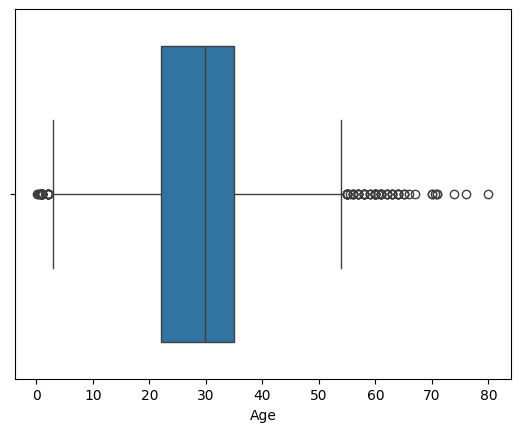

In [ ]:
sns.boxplot(x="Age", data=df1, color="#1f77b4")
plt.show()

In [ ]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df1[(df['Age']>= lower_bound) & (df['Age']<= upper_bound)]


/tmp/ipykernel_7257/666605074.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df1[(df['Age']>= lower_bound) & (df['Age']<= upper_bound)]


In [ ]:
outliner = df1[(df1['Age']<lower_bound) | (df1['Age']>upper_bound)]

In [ ]:
print(outliner)

      PassengerId  Survived  Pclass     Sex    Age  SibSp  Parch      Fare  \
7               8       0.0       3    male   2.00      3      1   21.0750   
10             11       1.0       3  female   4.00      1      1   16.7000   
11             12       1.0       1  female  58.00      0      0   26.5500   
16             17       0.0       3    male   2.00      4      1   29.1250   
33             34       0.0       2    male  66.00      0      0   10.5000   
...           ...       ...     ...     ...    ...    ...    ...       ...   
1234         1235       NaN       1  female  58.00      0      1  512.3292   
1245         1246       NaN       3  female   0.17      1      2   20.5750   
1247         1248       NaN       1  female  59.00      2      0   51.4792   
1278         1279       NaN       2    male  57.00      0      0   13.0000   
1300         1301       NaN       3  female   3.00      1      1   13.7750   

     Embarked  WikiId                                   Name_wi

In [ ]:
df2

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,male,22.0,1,0,7.2500,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,female,38.0,1,0,71.2833,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,female,26.0,0,0,7.9250,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,female,35.0,1,0,53.1000,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,male,35.0,0,0,8.0500,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1299,NaN,1,male,50.0,1,1,211.5000,C,316.0,"Widener, Mr. George Dunton",50.0,"Philadelphia, Pennsylvania, US",Southampton,"Philadelphia, Pennsylvania, US",NaN,NaN,1.0
1302,1303,NaN,1,female,37.0,1,0,90.0000,Q,206.0,"Minahan, Mrs. Lillian E. (née Thorpe)",37.0,"Fond du Lac, Wisconsin, US",Southampton,"Fond du Lac, Wisconsin, US",14,NaN,1.0
1303,1304,NaN,3,female,28.0,0,0,7.7750,S,869.0,"Henriksson, Miss Jenny Lovisa",28.0,"Stockholm, Sweden",Southampton,"Iron Mountain, Michigan, US",NaN,3MB,3.0
1305,1306,NaN,1,female,39.0,0,0,108.9000,C,229.0,"and maid, Doña Fermina Oliva y Ocana",39.0,"Madrid, Spain",Cherbourg,"New York, New York, US",8,NaN,1.0


In [ ]:
df2.isnull().sum()

,0
PassengerId,0
Survived,302
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
WikiId,3


In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,843
female,466


Index(['male'], dtype='object', name='Sex')


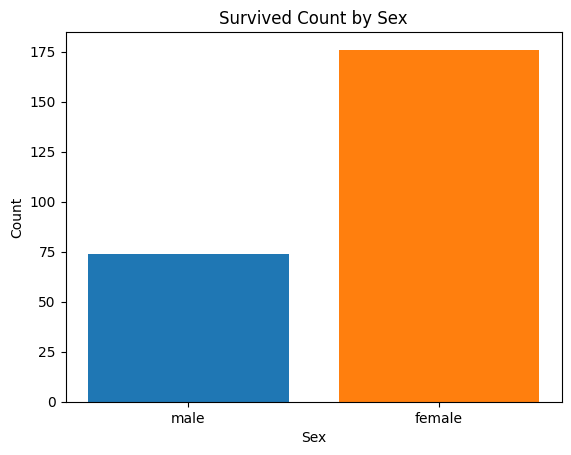

In [ ]:
survived_male = df2[(df2['Sex'] == 'male') & (df2['Survived'] == 1)]
survived_female = df2[(df2['Sex'] == 'female') & (df2['Survived'] == 1)]

plt.bar(survived_male['Sex'].value_counts().index, survived_male['Sex'].value_counts().values, label='Survived (Male)')
plt.bar(survived_female['Sex'].value_counts().index, survived_female['Sex'].value_counts().values, label='Survived (Female)')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Survived Count by Sex')





In [ ]:
print(survived_male)

     PassengerId  Survived  Pclass   Sex   Age  SibSp  Parch     Fare  \
21            22       1.0       2  male  34.0      0      0  13.0000   
23            24       1.0       1  male  28.0      0      0  35.5000   
74            75       1.0       3  male  32.0      0      0  56.4958   
81            82       1.0       3  male  29.0      0      0   9.5000   
97            98       1.0       1  male  23.0      0      1  63.3583   
..           ...       ...     ...   ...   ...    ...    ...      ...   
804          805       1.0       3  male  27.0      0      0   6.9750   
821          822       1.0       3  male  27.0      0      0   8.6625   
838          839       1.0       3  male  32.0      0      0  56.4958   
857          858       1.0       1  male  51.0      0      0  26.5500   
889          890       1.0       1  male  26.0      0      0  30.0000   

    Embarked  WikiId                        Name_wiki  Age_wiki  \
21         S   346.0            Beesley, Mr. Lawrence   

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
df4 = pd.read_csv ('/content/diabetes.csv')

In [ ]:
df4.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df4.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df4.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
763,False
764,False
765,False
766,False


AttributeError: 'numpy.ndarray' object has no attribute 'boxplot'

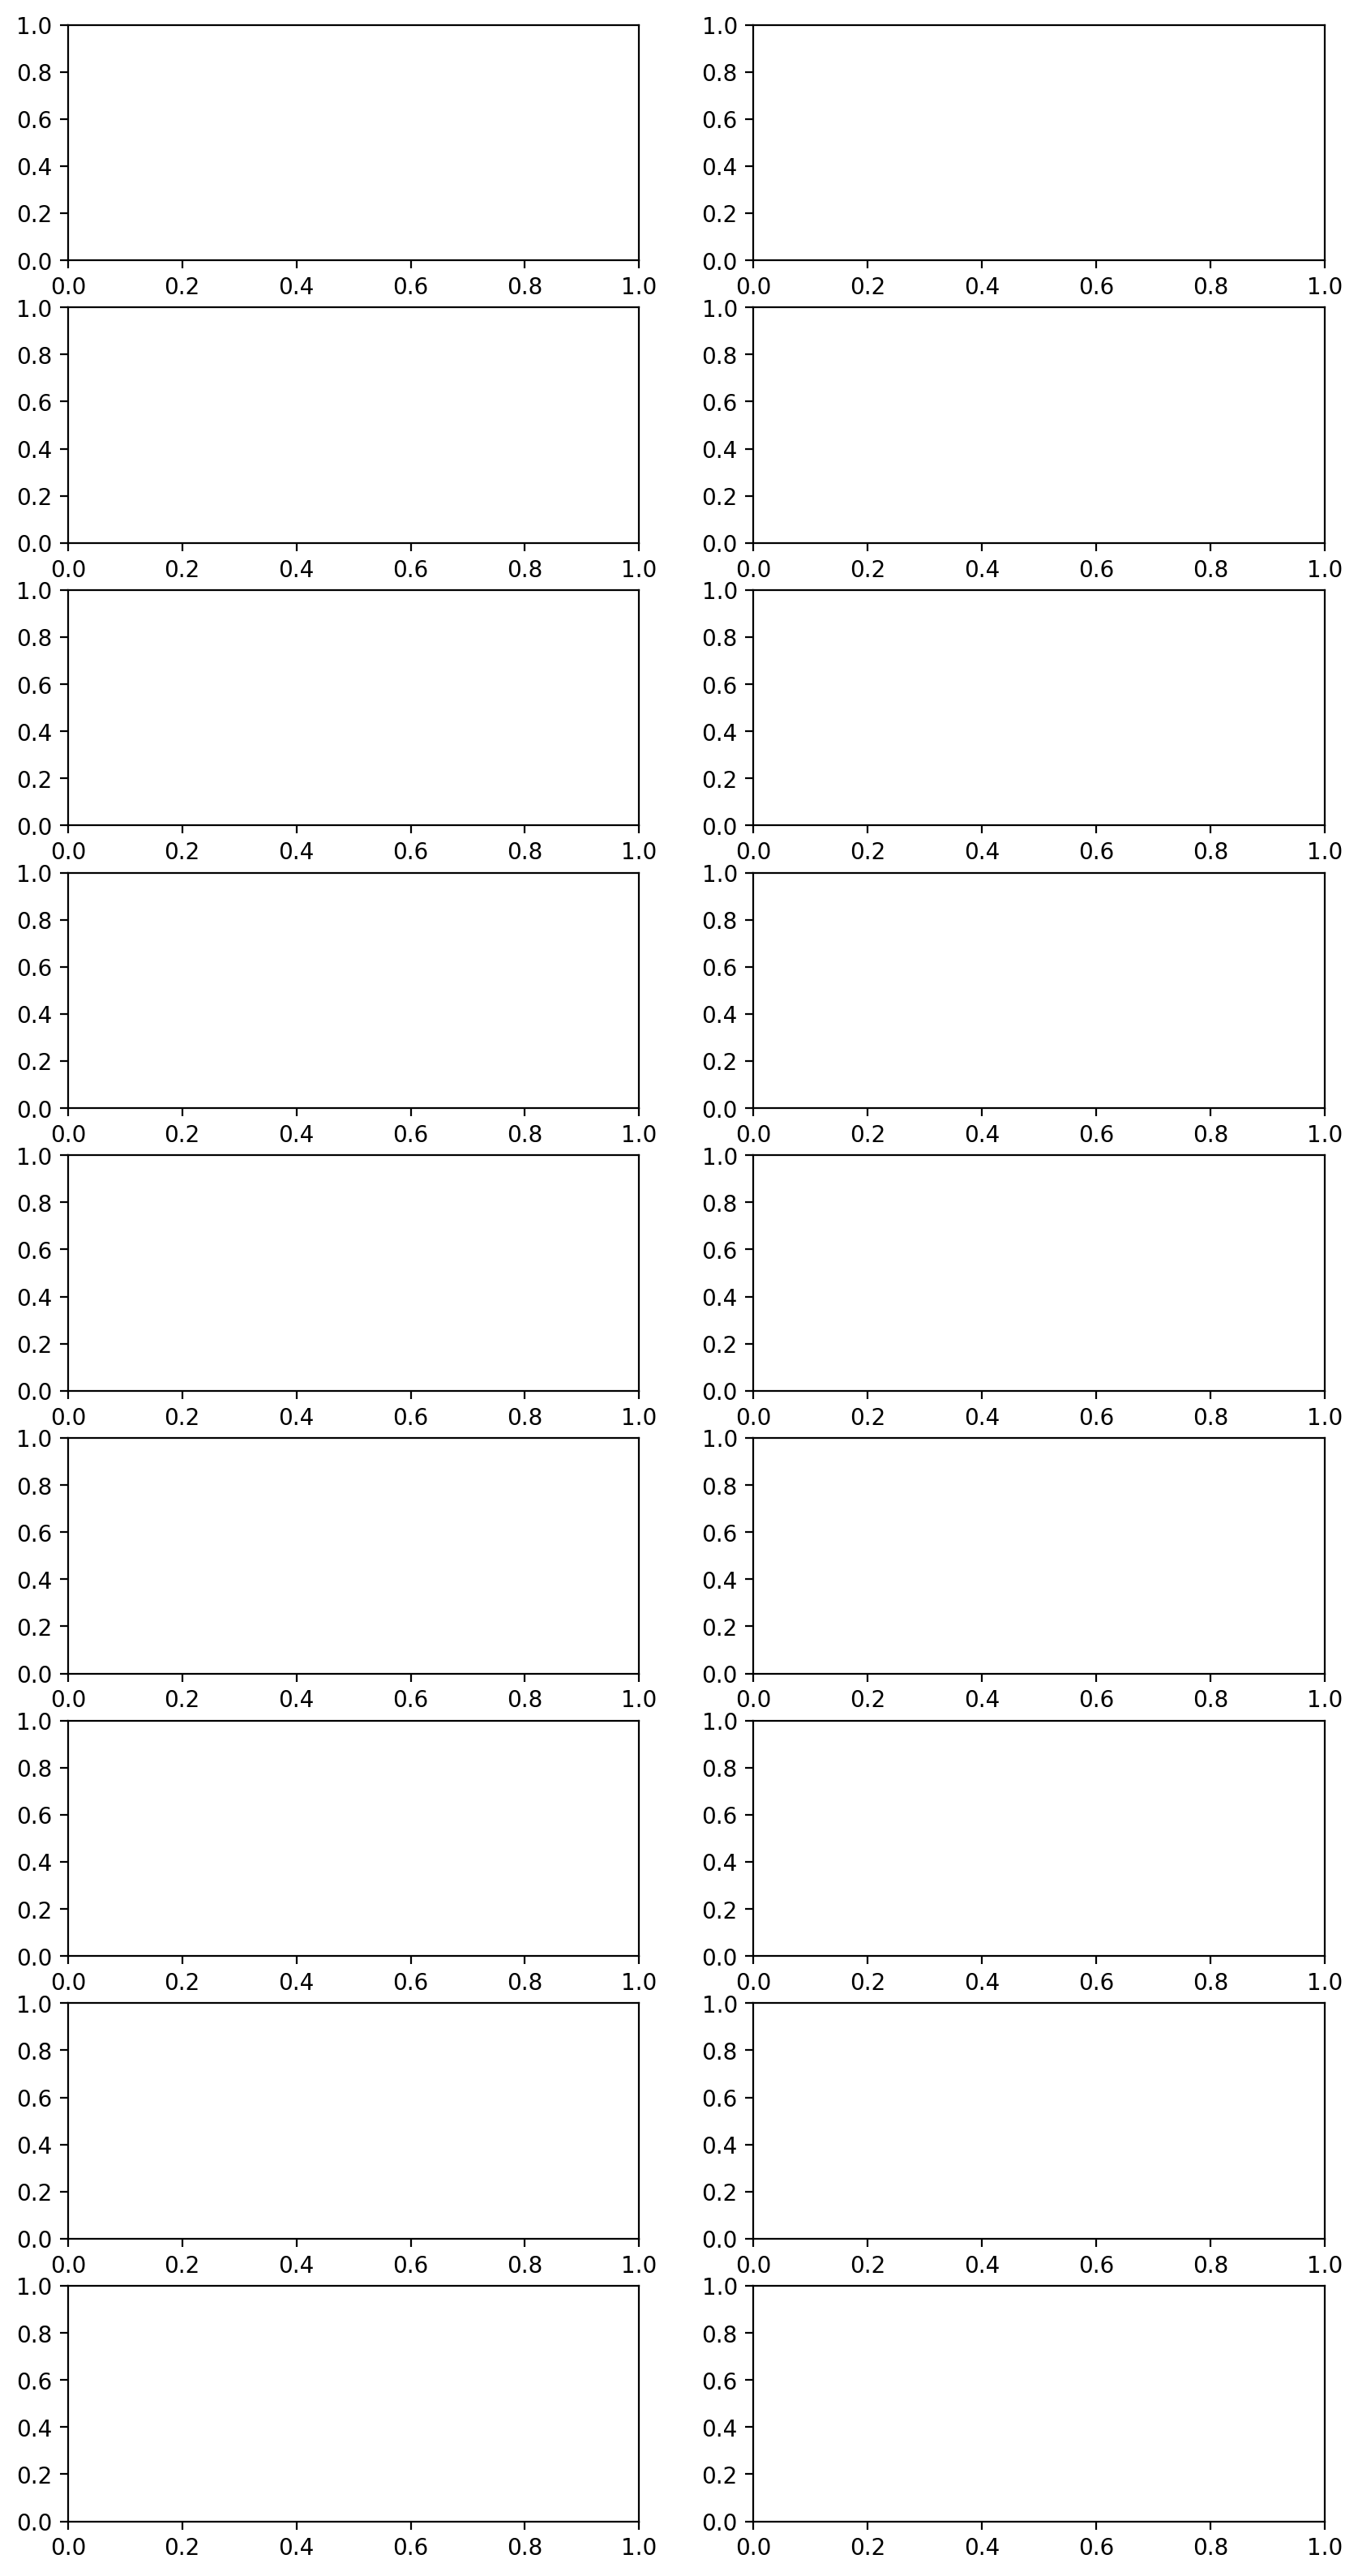

In [ ]:
fig, axs = plt.subplots(len(df4.columns), 2, figsize = (10, 20), dpi =200)
for i, col in enumerate(df4.columns):
  axs[i].boxplot(df4[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()
